# 03 - Feature Engineering

Our merged dataset has 85 columns, many of them:
- redundant
- contain significant missing values
- not useful for ML i.e, containing unique identifiers such as accident_index, etc.

So, we need to do some feature engineering, which will also help producing an intuitive result when analysing the data later.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dft = pd.read_csv('../data/STATS19/dft_STATS19_1979_23_SY.csv', low_memory=False)

### The Columns
Let's look at all the columns we have first.

In [10]:
# print(dft.shape)

# for i in dft.columns:
#   print(i)

##### We can start grouping these generally:

In [44]:
identifiers = [
  'accident_index', 
  'accident_year', 
  'accident_reference',
  'vehicle_reference', 
  'casualty_reference',
  'police_force',
  'local_authority_district', 
  'local_authority_ons_district'
]

outcomes = [
  'casualty_class',
  'casualty_severity',
  'casualty_type',
  'enhanced_casualty_severity',
  'enhanced_severity_collision',
  'accident_severity', 
  'number_of_vehicles',
  'number_of_casualties'
]

demographics = [
  'sex_of_casualty', 
  'age_of_casualty', 
  'age_band_of_casualty'
  'age_band_of_driver',
  'sex_of_driver', 
  'age_of_driver',
  'urban_or_rural_area',
  'pedestrian_location', 
  'pedestrian_movement',
  'car_passenger', 
  'bus_or_coach_passenger',
  'pedestrian_road_maintenance_worker',
  'driver_distance_banding',
  'casualty_distance_banding'
]

spatial = [
  'location_easting_osgr', 
  'location_northing_osgr', 
  'longitude',
  'latitude',
  'dir_from_e', 
  'dir_from_n', 
  'dir_to_e', 
  'dir_to_n'
]

imd = [
  'driver_home_area_type', 
  'lsoa_of_driver',
  'casualty_home_area_type', 
  'casualty_imd_decile', 
  'lsoa_of_casualty',
  'driver_imd_decile',
  'lsoa_of_accident_location'
]

environmental_conditions = [
  'light_conditions',
  'weather_conditions', 
  'road_surface_conditions',
  'pedestrian_crossing_human_control',
  'pedestrian_crossing_physical_facilities', 
  'special_conditions_at_site'
]

temporal = [
  'date', 
  'day_of_week', 
  'time'
]

vehicle_info = [
  'engine_capacity_cc',
  'propulsion_code',
  'age_of_vehicle', 
  'generic_make_model',
  'vehicle_type'
]

road_info = [
  'first_road_class', 
  'first_road_number',
  'road_type', 
  'speed_limit', 
  'junction_detail', 
  'junction_control',
  'second_road_class', 
  'second_road_number', 
  'local_authority_highway'
]

collision_info = [
  'vehicle_direction_from', 
  'vehicle_direction_to',
  'vehicle_location_restricted_lane', 
  'junction_location',
  'skidding_and_overturning',
  'hit_object_in_carriageway',
  'vehicle_leaving_carriageway', 
  'hit_object_off_carriageway',
  'first_point_of_impact', 
  'vehicle_left_hand_drive', 
  'carriageway_hazards',
  'did_police_officer_attend_scene_of_accident', 
  'trunk_road_flag', 
  'towing_and_articulation', 
  'vehicle_manoeuvre', 
  'journey_purpose_of_driver',
  'escooter_flag'
]

##### Removing columns not relevent/redundant

In [12]:
identifiers = [
  'accident_index', 
  'accident_year', 
  'vehicle_reference', 
  'casualty_reference',
]

outcomes = [
  'casualty_class',
  'casualty_severity',
  'casualty_type',
  'enhanced_casualty_severity',
  'enhanced_severity_collision',
  'accident_severity', 
  'number_of_vehicles',
  'number_of_casualties'
]

demographics = [
  'sex_of_casualty', 
  'age_of_casualty', 
  'sex_of_driver', 
  'age_of_driver',
  'urban_or_rural_area',
  'pedestrian_location', 
  'car_passenger', 
  'bus_or_coach_passenger',
  'pedestrian_road_maintenance_worker',
  'driver_distance_banding',
  'casualty_distance_banding'
]

imd = [
  'driver_home_area_type', 
  'lsoa_of_driver',
  'casualty_home_area_type', 
  'casualty_imd_decile', 
  'lsoa_of_casualty',
  'driver_imd_decile',
  'lsoa_of_accident_location'
]

environmental_conditions = [
  'light_conditions',
  'weather_conditions', 
  'road_surface_conditions',
  'pedestrian_crossing_human_control',
  'pedestrian_crossing_physical_facilities', 
  'special_conditions_at_site'
]

temporal = [
  'date', 
  'day_of_week', 
  'time'
]

vehicle_info = [
  'vehicle_type'
]

road_info = [
  'road_type', 
  'speed_limit', 
  'junction_detail', 
  'junction_control'
]

collision_info = [
  'junction_location',
  'hit_object_in_carriageway',
  'carriageway_hazards',
  'did_police_officer_attend_scene_of_accident', 
  'trunk_road_flag', 
  'journey_purpose_of_driver',
  'escooter_flag'
]

## ML

In [3]:
dft.head()
dft.dtypes

accident_index              object
accident_year                int64
accident_reference          object
vehicle_reference            int64
casualty_reference           int64
                            ...   
dir_from_e                 float64
dir_from_n                 float64
dir_to_e                   float64
dir_to_n                   float64
driver_distance_banding      int64
Length: 85, dtype: object

In [30]:
df= dft[dft['accident_year'] >= 2016].copy()

# # Save filtered dataset
# df_filtered.to_csv('filtered_dataset.csv', index=False)

rm_col = ['accident_reference','police_force','local_authority_district','local_authority_ons_district'] + spatial + vehicle_info

def stats(dft, label):
  print(f"\n-------\n{label}\n--------")
  print(f"{label} has {dft.shape[0]} rows and {dft.shape[1]} columns.")

  size_mb = dft.memory_usage(deep=True).sum() / (1024 * 1024)
  print(f"{label} size: {size_mb:.2f} MB")
  return

df2 = df.drop(columns=rm_col)

stats(dft, 'Original Dataset')
stats(df, 'Year Filtered Dataset')
stats(df2, 'Column removed Dataset')



-------
Original Dataset
--------
Original Dataset has 243191 rows and 85 columns.
Original Dataset size: 269.67 MB

-------
Year Filtered Dataset
--------
Year Filtered Dataset has 25759 rows and 85 columns.
Year Filtered Dataset size: 29.17 MB

-------
Column removed Dataset
--------
Column removed Dataset has 25759 rows and 72 columns.
Column removed Dataset size: 24.16 MB


In [32]:
import sys
sys.path.append('../utilities')
import interactive_column_plotter as icp

# icp.advanced_missing_explorer(df2)

In [39]:
import sys
sys.path.append('../utilities')
import interactive_column_plotter as icp


# Boolean DataFrame: True if value is NaN, -1, or -1.0
is_missing = df2.isnull() | (df2 == -1) | (df2 == -1.0)

# Count total missing values
total_missing = is_missing.sum().sum()

# Total number of cells
total_cells = df2.shape[0] * df2.shape[1]

# Percentage missing
percent_missing = (total_missing / total_cells) * 100

print(f"Total missing (including -1, -1.0): {total_missing} cells ({percent_missing:.2f}% of all data)")



Total missing (including -1, -1.0): 76679 cells (4.13% of all data)


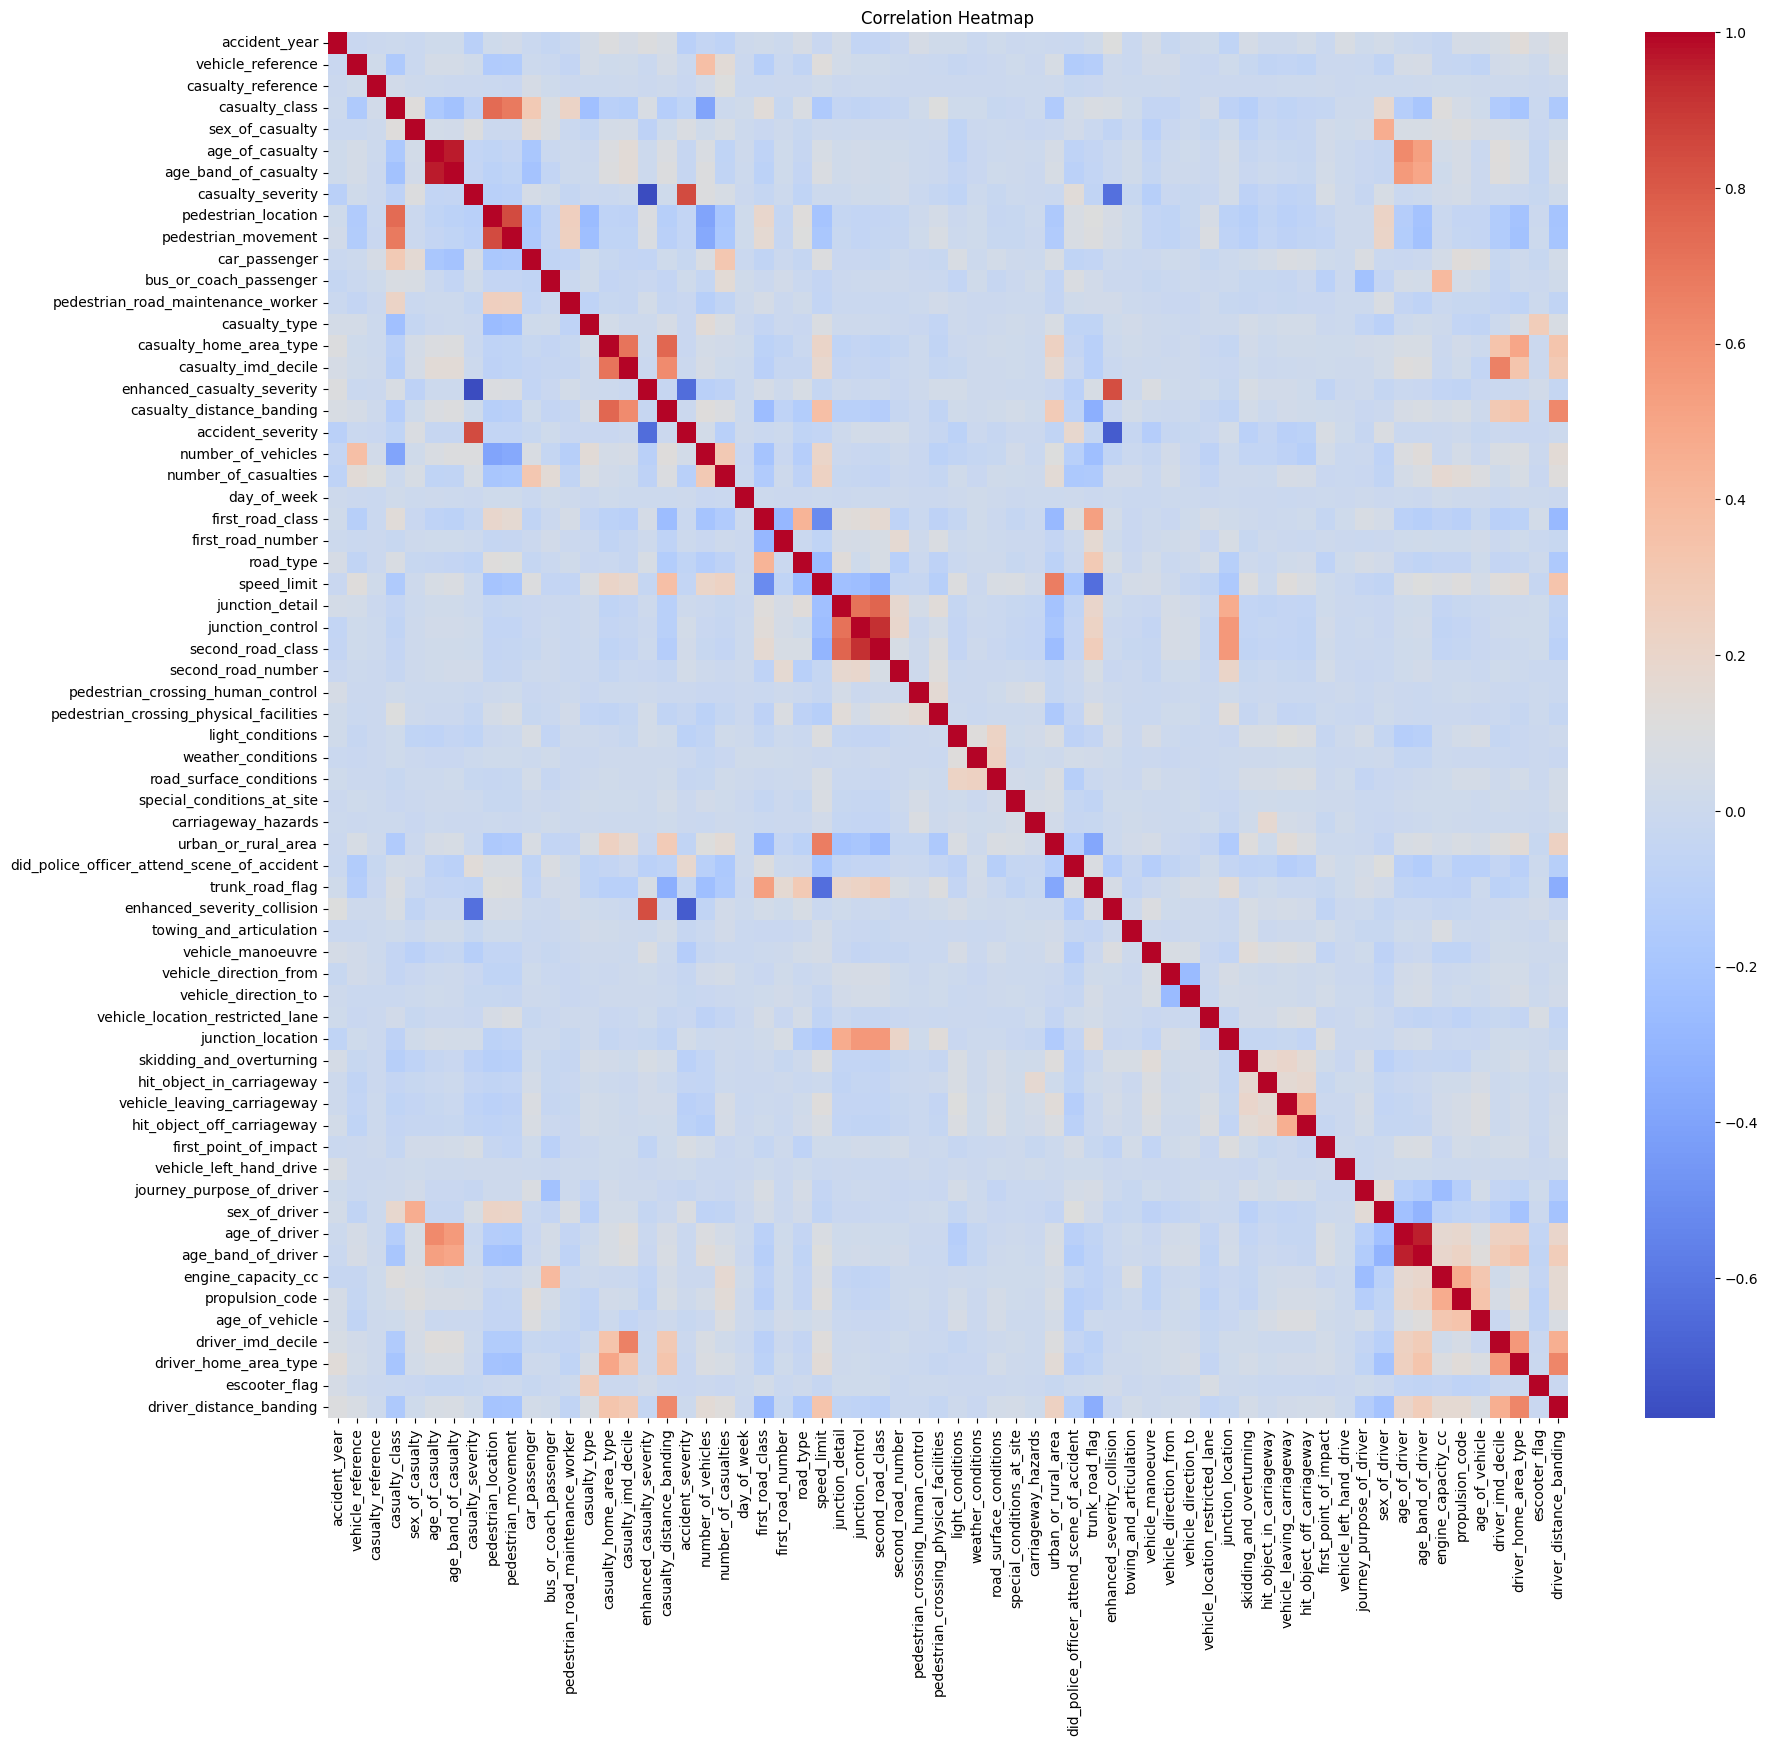

In [43]:
corr_matrix = df2.corr(numeric_only=True)
# print(corr_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,18))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



In [47]:
corr_matrix = dft.corr(numeric_only=True)
targets = ['number_of_casualties', 'number_of_vehicles', 'casualty_severity', 'pedestrian_location', 'casualty_type']
for target in targets:
    corr = corr_matrix[target].sort_values(ascending=False)
    print(f"\nTop correlations with {target}:\n{corr.head(10)}")



Top correlations with number_of_casualties:
number_of_casualties      1.000000
casualty_reference        0.406913
car_passenger             0.242086
number_of_vehicles        0.224536
speed_limit               0.140860
vehicle_reference         0.133687
bus_or_coach_passenger    0.114626
casualty_type             0.104925
propulsion_code           0.092285
age_of_vehicle            0.076189
Name: number_of_casualties, dtype: float64

Top correlations with number_of_vehicles:
number_of_vehicles           1.000000
vehicle_reference            0.554751
number_of_casualties         0.224536
casualty_type                0.208011
speed_limit                  0.188826
urban_or_rural_area          0.147110
accident_year                0.129975
driver_distance_banding      0.124659
casualty_distance_banding    0.121181
driver_home_area_type        0.105070
Name: number_of_vehicles, dtype: float64

Top correlations with casualty_severity:
casualty_severity           1.000000
accident_severity  